# BayesFlow Ratio Estimation with HSSM Utilities

This notebook demonstrates that **HSSM already contains all the infrastructure**
needed to take a trained BayesFlow `RatioApproximator` and turn it into a
fully functional `pm.Distribution` with gradient support for NUTS sampling.

The previous notebook (`Ratio_Estimation_new_ssms.ipynb`) built the bridge
manually by replicating ~150 lines of PyTensor Op and distribution code.
Here we import HSSM's existing utilities directly and show the same result
in **~10 lines of glue code**.

**Pipeline:**

1. Train (or load) a BayesFlow `RatioApproximator` on DDM data
2. Extract a pure JAX single-trial log-ratio function
3. Use HSSM's `make_jax_logp_funcs_from_callable` to create vmapped + VJP functions
4. Use HSSM's `make_jax_logp_ops` to wrap them in PyTensor Ops
5. Use HSSM's `make_distribution` to create a proper `pm.Distribution`
6. Run NUTS sampling via PyMC

---
## Part 1: Train (or Load) the Ratio Estimator

This part is identical to the previous notebook. We train a BayesFlow
`RatioApproximator` on DDM data generated by `ssm-simulators`, then
extract a pure JAX single-trial function.

In [1]:
import os
os.environ["KERAS_BACKEND"] = "jax"

import bayesflow as bf
import keras
import numpy as np
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp

import pymc as pm

from ssms.basic_simulators.simulator import simulator as ssm_simulator
from ssms.config import model_config as ssms_model_config

print(f"JAX backend: {keras.backend.backend()}")
print(f"JAX devices: {jax.devices()}")

INFO:2026-02-18 01:46:11,705:jax._src.xla_bridge:834: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache), 'libtpu.so' (no such file)
INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache), 'libtpu.so' (no such file)
INFO:bayesflow:Using backend 'jax'
/Users/afengler/Library/CloudStorage/OneDrive-Personal/proj_bayesflow/bayesflow/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
INFO

JAX backend: jax
JAX devices: [CpuDevice(id=0)]


In [2]:
LOAD_PRETRAINED = True  # <-- Set to True to skip training and load from disk
PRE_TRAINED_NAME = "ddm_ratio_approximator.keras"
SAVE_DIR = "trained_models" 

### DDM Configuration

In [3]:
# Read DDM config from ssm-simulators
ddm_cfg = ssms_model_config["ddm"]
param_names = ddm_cfg["params"]
param_lower = np.array(ddm_cfg["param_bounds"][0])
param_upper = np.array(ddm_cfg["param_bounds"][1])
param_defaults = np.array(ddm_cfg["default_params"])

print("DDM parameters:")
for name, lo, hi, default in zip(param_names, param_lower, param_upper, param_defaults):
    print(f"  {name:5s}: bounds=[{lo:5.2f}, {hi:5.2f}], default={default}")

DDM parameters:
  v    : bounds=[-3.00,  3.00], default=0.0
  a    : bounds=[ 0.30,  2.50], default=1.0
  z    : bounds=[ 0.10,  0.90], default=0.5
  t    : bounds=[ 0.00,  2.00], default=0.001


### Generative Model

In [4]:
help(ssm_simulator)

Help on function simulator in module ssms.basic_simulators.simulator:

simulator(theta: list | numpy.ndarray | dict | pandas.DataFrame, model: str = 'angle', n_samples: int = 1000, delta_t: float = 0.001, max_t: float = 20, no_noise: bool = False, sigma_noise: float | None = None, smooth_unif: bool = True, random_state: int | None = None) -> dict
    Basic data simulator for the models included in HDDM.

    Arguments
    ---------
        theta : list, numpy.array, dict or pd.DataFrame
            Parameters of the simulator. If 2d array, each row is treated as a 'trial'
            and the function runs n_sample * n_trials simulations.
        deadline : numpy.array <default=None>
            If supplied, the simulator will run a deadline model. RTs will be returned
        model: str <default='angle'>
            Determines the model that will be simulated.
        n_samples: int <default=1000>
            Number of simulation runs for each row in the theta argument.
        delta_t

In [5]:
def prior():
    params = {}
    for name, lo, hi in zip(param_names, param_lower, param_upper):
        params[name] = np.random.uniform(lo, hi)
    return params

def likelihood(v, a, z, t):
    result = ssm_simulator(theta={"v": v, "a": a, "z": z, "t": t}, 
                           model="ddm",
                           n_samples=1,
                           delta_t = 0.001,
                           )
    rt = float(result["rts"].flat[0])
    choice = float(result["choices"].flat[0])
    return {"obs": np.array([rt, choice], dtype=np.float32)}

simulator = bf.make_simulator([prior, likelihood])

### Build, Train & Save (skipped if `LOAD_PRETRAINED = True`)

In [6]:
if not LOAD_PRETRAINED:
    adapter = bf.approximators.RatioApproximator.build_adapter(
        inference_variables=["v", "a", "z", "t"],
        inference_conditions=["obs"],
    )

    ratio_approximator = bf.approximators.RatioApproximator(
        adapter=adapter,
        classifier_network=bf.networks.MLP(widths=[256, 256, 256]),
        standardize=None,
    )

    ratio_approximator.compile(optimizer="adam")
    history = ratio_approximator.fit(
        simulator=simulator, epochs=150, num_batches=200, batch_size=64,
    )
    f = bf.diagnostics.plots.loss(history)

    os.makedirs(SAVE_DIR, exist_ok=True)
    ratio_approximator.save(os.path.join(SAVE_DIR, PRE_TRAINED_NAME))
    print(f"Saved to {SAVE_DIR}/{PRE_TRAINED_NAME}")

### Load Pre-trained Approximator

In [7]:
if LOAD_PRETRAINED:
    load_path = os.path.join(SAVE_DIR, PRE_TRAINED_NAME)
    ratio_approximator = keras.saving.load_model(load_path)
    print(f"Loaded from: {load_path}")
else:
    print("Using in-memory approximator from training above.")

Loaded from: trained_models/ddm_ratio_approximator.keras


### Extract JAX Single-Trial Function

This is the key function that turns a trained Keras model into a pure JAX callable
with signature `f(obs_i, v, a, z, t) -> scalar log_ratio`.

In [8]:
def make_jax_log_ratio_fn(ratio_approximator):
    """Extract a pure JAX single-trial log-ratio callable.

    Returns f(obs_i, v, a, z, t) -> scalar log_ratio
    where obs_i is shape (2,) = [rt, choice] and params are scalars.
    """
    classifier = ratio_approximator.classifier_network
    projector = ratio_approximator.projector

    std_layers = ratio_approximator.standardize_layers if hasattr(ratio_approximator, "standardize_layers") else {}
    std_keys = ratio_approximator.standardize if hasattr(ratio_approximator, "standardize") else []
    if std_layers is None:
        std_layers = {}
    if std_keys is None:
        std_keys = []

    def single_trial_log_ratio(obs_i, *params):
        inf_vars = jnp.array(list(params))
        inf_conds = jnp.atleast_1d(obs_i)

        if "inference_variables" in std_keys and "inference_variables" in std_layers:
            inf_vars = std_layers["inference_variables"](inf_vars[None, :], training=False)[0]
        if "inference_conditions" in std_keys and "inference_conditions" in std_layers:
            inf_conds = std_layers["inference_conditions"](inf_conds[None, :], training=False)[0]

        classifier_input = jnp.concatenate([inf_vars, inf_conds])
        hidden = classifier(classifier_input[None, :], training=False)
        logits = projector(hidden, training=False)
        return jnp.squeeze(logits)

    return single_trial_log_ratio


single_trial_fn = make_jax_log_ratio_fn(ratio_approximator)

# Quick test
test_obs = jnp.array([0.8, 1.0])
test_val = single_trial_fn(test_obs, jnp.array(0.5), jnp.array(1.0), jnp.array(0.5), jnp.array(0.3))
print(f"Single trial log-ratio at (obs=[0.8, 1.0], v=0.5, a=1.0, z=0.5, t=0.3): {test_val:.4f}")

Single trial log-ratio at (obs=[0.8, 1.0], v=0.5, a=1.0, z=0.5, t=0.3): 1.5474


---
## Part 2: The HSSM Bridge (~10 Lines)

This is the key part of the notebook. Instead of manually writing ~150 lines of
PyTensor Op code and `pm.Distribution` boilerplate, we import three functions
from HSSM's `distribution_utils` module:

| Function | What it does |
|---|---|
| `make_jax_logp_funcs_from_callable` | vmap + VJP wrapping of the single-trial function |
| `make_jax_logp_ops` | Wrap JAX functions in PyTensor Ops with gradient support |
| `make_distribution` | Create a full `pm.Distribution` with bounds, NDT checks, lapse support |

Plus `make_hssm_rv` to create a `RandomVariable` (needed for prior/posterior predictive sampling).

In [9]:
# The HSSM imports -- this is all we need
from hssm.distribution_utils.jax import make_jax_logp_funcs_from_callable, make_jax_logp_ops
from hssm.distribution_utils.dist import make_distribution, make_hssm_rv

print("HSSM distribution utilities imported successfully.")

HSSM distribution utilities imported successfully.


### Step A: Vectorize + VJP

`make_jax_logp_funcs_from_callable` takes our single-trial JAX function and produces:
- A vmapped (vectorized over trials) version
- A VJP (Vector-Jacobian Product) for gradient computation
- A non-JIT version for PyTensor's JAX backend dispatch

In [10]:
# Step A: vmap + VJP
logp_jit, logp_vjp_jit, logp_nojit = make_jax_logp_funcs_from_callable(
    single_trial_fn,
    vmap=True,
    params_is_reg=[True, True, True, True],  # all 4 DDM params as trial-wise vectors
)
print("Vectorized + VJP functions created.")

params_only:  False
params_is_reg:  [True, True, True, True]
Vectorized + VJP functions created.


### Step B: PyTensor Ops

`make_jax_logp_ops` wraps the JAX functions in PyTensor `Op`s that:
- Support `perform()` for eager evaluation
- Support `grad()` via the VJP Op
- Register with `jax_funcify` for native JAX backend sampling

In [11]:
# Step B: PyTensor Ops with gradient support
ratio_op = make_jax_logp_ops(logp_jit, logp_vjp_jit, logp_nojit)
print("PyTensor Op created:", ratio_op)

PyTensor Op created: LANLogpOp


### Step C: RandomVariable

`make_hssm_rv` creates a `RandomVariable` class that knows how to simulate from
the DDM using `ssm-simulators`. This enables prior/posterior predictive checks.

In [12]:
# Step C: RandomVariable for sampling
DDM_RV = make_hssm_rv(
    simulator_fun="ddm",
    list_params=["v", "a", "z", "t"],
    lapse=None,
)
print("RandomVariable class:", DDM_RV)
print("Signature:", DDM_RV.signature)

RandomVariable class: <class 'hssm.distribution_utils.dist.make_hssm_rv.<locals>.HSSMRV'>
Signature: (),(),(),()->(2)


### Step D: pm.Distribution

`make_distribution` creates a complete `pm.Distribution` subclass that:
- Uses the PyTensor Op for `logp()` computation
- Applies parameter bounds checking (returns log-prob floor when out of bounds)
- Validates non-decision time < reaction time
- Supports trial-wise parameter broadcasting
- Has lapse model support (not used here, but available)

In [13]:
# Step D: Full pm.Distribution
# Define parameter bounds matching the training regime
ddm_bounds = {
    "v": (-3.0, 3.0),
    "a": (0.3, 2.5),
    "z": (0.1, 0.9),
    "t": (0.0, 2.0),
}

DDMRatioDistribution = make_distribution(
    rv=DDM_RV,
    loglik=ratio_op,
    list_params=["v", "a", "z", "t"],
    bounds=ddm_bounds,
    lapse=None,
    params_is_trialwise=[True, True, True, True],
)

print("pm.Distribution created:", DDMRatioDistribution)

pm.Distribution created: <class 'hssm.distribution_utils.dist.make_distribution.<locals>.HSSMDistribution'>


### Summary: The Complete Bridge

That's it. The entire bridge from a trained BayesFlow `RatioApproximator` to
a PyMC `pm.Distribution` is:

```python
# 1. Extract JAX function
single_trial_fn = make_jax_log_ratio_fn(ratio_approximator)

# 2. Vectorize + VJP  (HSSM utility)
logp_jit, logp_vjp_jit, logp_nojit = make_jax_logp_funcs_from_callable(
    single_trial_fn, vmap=True, params_is_reg=[True]*4,
)

# 3. PyTensor Ops  (HSSM utility)
ratio_op = make_jax_logp_ops(logp_jit, logp_vjp_jit, logp_nojit)

# 4. pm.Distribution  (HSSM utility)
DDMRatioDistribution = make_distribution(
    rv="ddm", loglik=ratio_op, list_params=["v","a","z","t"], bounds=ddm_bounds,
)
```

Compare this with the ~150 lines of manual `LANLogpOp`, `LANLogpVJPOp`,
`jax_funcify.register`, `SimpleRV`, and `RatioDistribution` code in the
previous notebook.

---
## Part 3: PyMC Model with NUTS Sampling

We use the HSSM-created distribution in a standard PyMC model with NUTS.
The setup is identical to the previous notebook.

### Generate Observed Data

In [14]:
# Ground truth parameters
v_true = 0.5
a_true = 1.5
z_true = 0.5
t_true = 0.3
n_obs = 250

# Simulate observed data
result = ssm_simulator(
    theta={"v": v_true, "a": a_true, "z": z_true, "t": t_true},
    model="ddm", n_samples=n_obs, random_state=42, delta_t = 0.001,
)

x_observed = np.column_stack([
    result["rts"].flatten(),
    result["choices"].flatten(),
]).astype(np.float32)

print(f"Observed data: n={n_obs}")
print(f"  RT mean={x_observed[:, 0].mean():.3f}, std={x_observed[:, 0].std():.3f}")
print(f"  Choices: -1={int((x_observed[:,1]==-1).sum())}, +1={int((x_observed[:,1]==1).sum())}")
print(f"True params: v={v_true}, a={a_true}, z={z_true}, t={t_true}")

Observed data: n=250
  RT mean=2.393, std=1.712
  Choices: -1=44, +1=206
True params: v=0.5, a=1.5, z=0.5, t=0.3


### Build and Sample the Model

In [15]:
with pm.Model() as ddm_model:
    # Truncated priors matching the training bounds
    v = pm.TruncatedNormal("v", mu=0, sigma=1.5, lower=-3.0, upper=3.0)
    a = pm.TruncatedNormal("a", mu=1.0, sigma=0.5, lower=0.3, upper=2.5)
    z = pm.TruncatedNormal("z", mu=0.5, sigma=0.2, lower=0.1, upper=0.9)
    t = pm.TruncatedNormal("t", mu=0.3, sigma=0.3, lower=0.0, upper=2.0)

    obs = DDMRatioDistribution("obs", v=v, a=a, z=z, t=t, observed=x_observed)

    trace = pm.sample(
        1000,
        nuts_sampler="numpyro",
        chains=2,
        tune=1000,
        random_seed=42,
        initvals={"v": 0.0, "a": 1.0, "z": 0.5, "t": 0.3},
    )

/Users/afengler/Library/CloudStorage/OneDrive-Personal/proj_bayesflow/bayesflow/.venv/lib/python3.12/site-packages/pymc/sampling/jax.py:475: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  pmap_numpyro = MCMC(
sample: 100%|██████████| 2000/2000 [00:30<00:00, 65.48it/s, 7 steps of size 5.10e-01. acc. prob=0.90] 
INFO:pymc.stats.convergence:We recommend running at least 4 chains for robust computation of convergence diagnostics


### Diagnostics

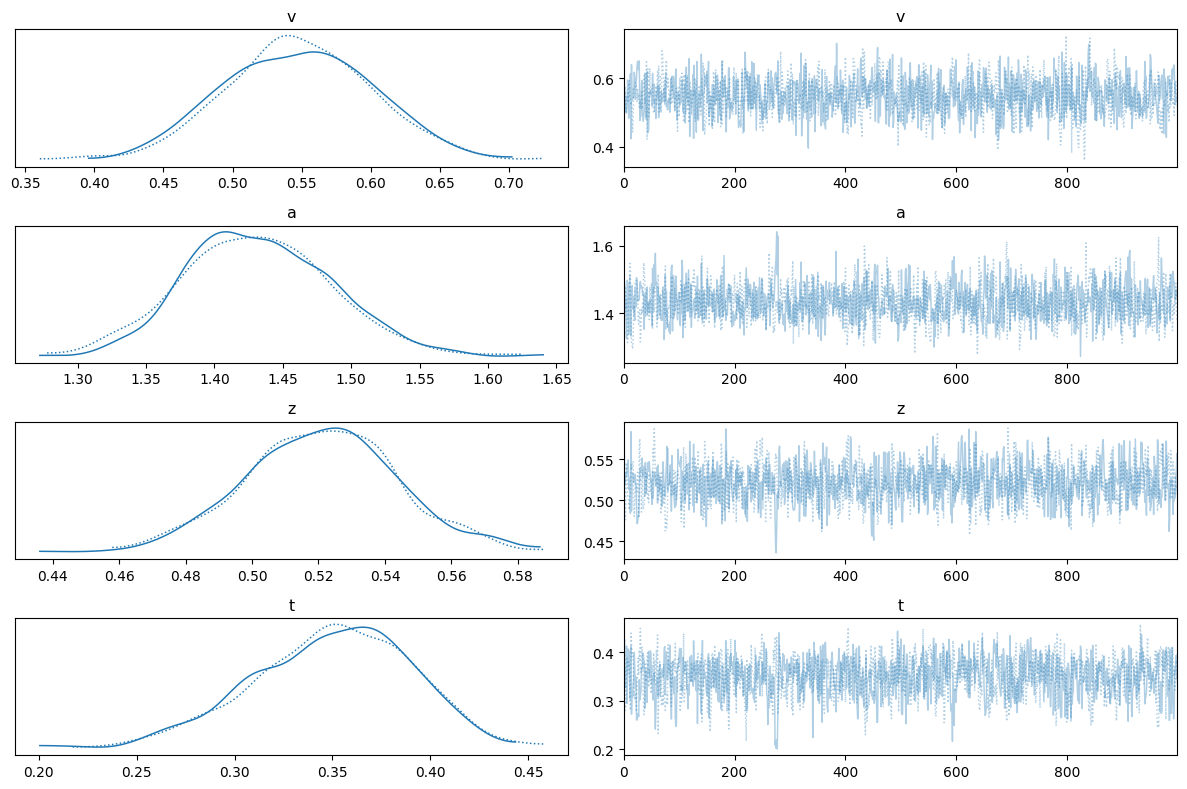

    mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
v  0.548  0.053   0.453    0.650      0.002    0.001    1126.0    1240.0   
a  1.432  0.053   1.330    1.528      0.001    0.001    1358.0    1311.0   
z  0.521  0.023   0.476    0.564      0.001    0.000    1249.0    1219.0   
t  0.349  0.040   0.272    0.420      0.001    0.001    1037.0    1004.0   

   r_hat  
v    1.0  
a    1.0  
z    1.0  
t    1.0  

True values: v=0.5, a=1.5, z=0.5, t=0.3


In [16]:
import arviz as az

az.plot_trace(trace, var_names=["v", "a", "z", "t"])
plt.tight_layout()
plt.show()

print(az.summary(trace, var_names=["v", "a", "z", "t"]))
print(f"\nTrue values: v={v_true}, a={a_true}, z={z_true}, t={t_true}")

### Posterior vs. True Values

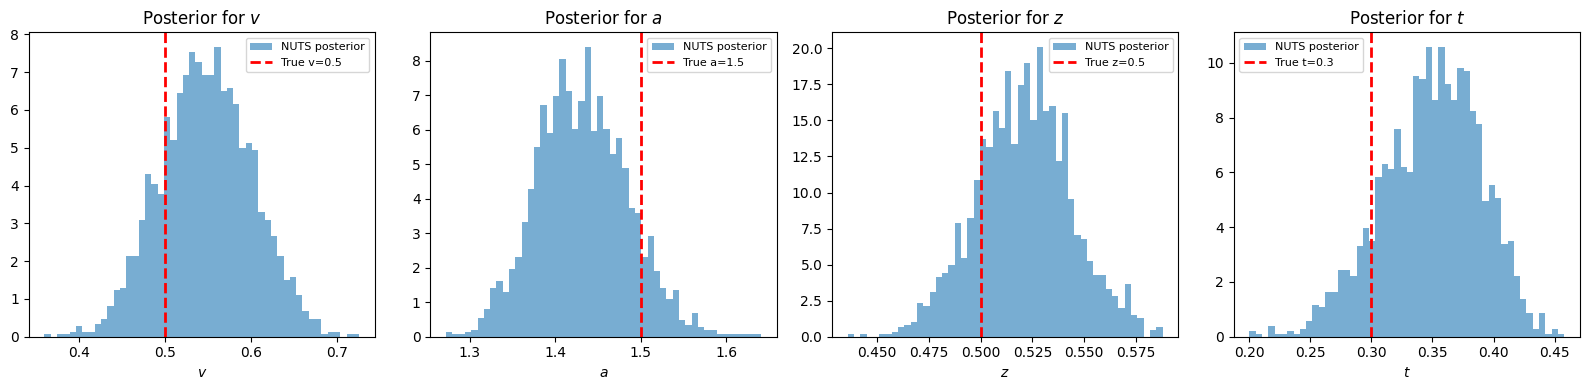

In [17]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for i, (name, true_val) in enumerate([
    ("v", v_true), ("a", a_true), ("z", z_true), ("t", t_true)
]):
    samples = trace.posterior[name].values.flatten()
    axes[i].hist(samples, bins=50, density=True, alpha=0.6, label="NUTS posterior")
    axes[i].axvline(true_val, color="r", linestyle="--", linewidth=2, label=f"True {name}={true_val}")
    axes[i].set_xlabel(f"${name}$")
    axes[i].set_title(f"Posterior for ${name}$")
    axes[i].legend(fontsize=8)

plt.tight_layout()
plt.show()

### Posterior Predictive Check

Because we used `make_hssm_rv("ddm", ...)` to create the `RandomVariable`,
the distribution knows how to simulate new DDM trials via `ssm-simulators`.
This means `pm.sample_posterior_predictive` works out of the box -- a key
advantage of using HSSM's utilities over the manual approach.

INFO:pymc.sampling.forward:Sampling: [obs]


/Users/afengler/Library/CloudStorage/OneDrive-Personal/proj_bayesflow/bayesflow/.venv/lib/python3.12/site-packages/
rich/live.py:260: UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

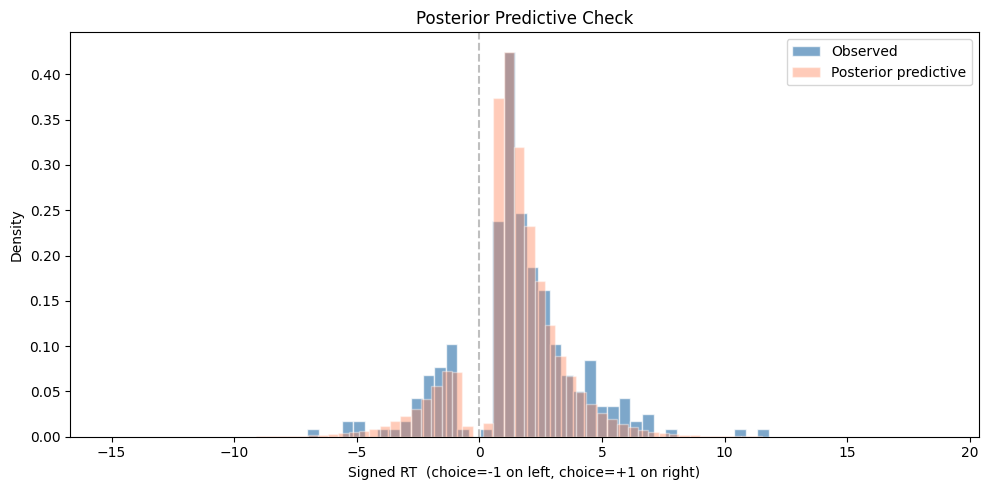

In [18]:
# Generate posterior predictive samples
with ddm_model:
    ppc = pm.sample_posterior_predictive(trace, random_seed=42)

# Extract posterior predictive RT and choice arrays
ppc_obs = ppc.posterior_predictive["obs"].values  # shape: (chains, draws, n_obs, 2)
ppc_rt = ppc_obs[..., 0].flatten()
ppc_choice = ppc_obs[..., 1].flatten()

obs_rt = x_observed[:, 0]
obs_choice = x_observed[:, 1]

# Signed RT: multiply rt by choice so that choice=-1 appears on the negative x-axis
obs_signed_rt = obs_rt * obs_choice
ppc_signed_rt = ppc_rt * ppc_choice

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(obs_signed_rt, bins=40, density=True, alpha=0.7,
        label="Observed", color="steelblue", edgecolor="white")
ax.hist(ppc_signed_rt, bins=80, density=True, alpha=0.4,
        label="Posterior predictive", color="coral", edgecolor="white")

ax.axvline(0, color="gray", linestyle="--", alpha=0.5)
ax.set_xlabel("Signed RT  (choice=-1 on left, choice=+1 on right)")
ax.set_ylabel("Density")
ax.set_title("Posterior Predictive Check")
ax.legend()
plt.tight_layout()
plt.show()

---
## Part 4: Comparison with Analytical and LAN DDM Likelihoods

HSSM ships both an **analytical** Wiener first-passage time (WFPT) likelihood
and a pre-trained **Likelihood Approximation Network (LAN)** for the DDM.
We can create `pm.Distribution` objects for each using a single call to
`make_distribution_for_supported_model`.

By fitting the **same observed data** with the **same priors**, we get a
three-way comparison:

1. **BayesFlow NRE** -- the ratio estimator we trained in this notebook
2. **HSSM Analytical** -- the exact WFPT likelihood (`loglik_kind="analytical"`)
3. **HSSM LAN** -- pre-trained neural network likelihood (`loglik_kind="approx_differentiable"`)

In [19]:
from hssm.distribution_utils import make_distribution_for_supported_model

# One-liner: analytical WFPT distribution for DDM
AnalyticalDDM = make_distribution_for_supported_model(
    "ddm", loglik_kind="analytical", backend="pytensor",
)
print("Analytical DDM distribution created:", AnalyticalDDM)

# Fit with identical priors and observed data
with pm.Model() as analytical_model:
    v_a = pm.TruncatedNormal("v", mu=0, sigma=1.5, lower=-3.0, upper=3.0)
    a_a = pm.TruncatedNormal("a", mu=1.0, sigma=0.5, lower=0.3, upper=2.5)
    z_a = pm.TruncatedNormal("z", mu=0.5, sigma=0.2, lower=0.1, upper=0.9)
    t_a = pm.TruncatedNormal("t", mu=0.3, sigma=0.3, lower=0.0, upper=2.0)

    obs_a = AnalyticalDDM("obs", v=v_a, a=a_a, z=z_a, t=t_a, observed=x_observed)

    trace_analytical = pm.sample(
        1000,
        nuts_sampler="numpyro",
        chains=4,
        tune=1000,
        random_seed=42,
        initvals={"v": 0.0, "a": 1.0, "z": 0.5, "t": 0.3},
    )

Analytical DDM distribution created: <class 'hssm.distribution_utils.dist.make_distribution.<locals>.HSSMDistribution'>


/Users/afengler/Library/CloudStorage/OneDrive-Personal/proj_bayesflow/bayesflow/.venv/lib/python3.12/site-packages/pymc/sampling/jax.py:475: UserWarning: There are not enough devices to run parallel chains: expected 4 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(4)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  pmap_numpyro = MCMC(
sample: 100%|██████████| 2000/2000 [00:03<00:00, 580.78it/s, 11 steps of size 4.02e-01. acc. prob=0.92]


### Fit with HSSM's Pre-trained LAN

In [20]:
# LAN-based DDM distribution (pre-trained neural network likelihood)
LANDDM = make_distribution_for_supported_model(
    "ddm", loglik_kind="approx_differentiable", backend="pytensor",
)
print("LAN DDM distribution created:", LANDDM)

with pm.Model() as lan_model:
    v_l = pm.TruncatedNormal("v", mu=0, sigma=1.5, lower=-3.0, upper=3.0)
    a_l = pm.TruncatedNormal("a", mu=1.0, sigma=0.5, lower=0.3, upper=2.5)
    z_l = pm.TruncatedNormal("z", mu=0.5, sigma=0.2, lower=0.1, upper=0.9)
    t_l = pm.TruncatedNormal("t", mu=0.3, sigma=0.3, lower=0.0, upper=2.0)

    obs_l = LANDDM("obs", v=v_l, a=a_l, z=z_l, t=t_l, observed=x_observed)

    trace_lan = pm.sample(
        1000,
        nuts_sampler="numpyro",
        chains=4,
        tune=1000,
        random_seed=42,
        initvals={"v": 0.0, "a": 1.0, "z": 0.5, "t": 0.3},
    )

INFO:httpx:HTTP Request: HEAD https://huggingface.co/franklab/HSSM/resolve/main/ddm.onnx "HTTP/1.1 302 Found"


LAN DDM distribution created: <class 'hssm.distribution_utils.dist.make_distribution.<locals>.HSSMDistribution'>


/Users/afengler/Library/CloudStorage/OneDrive-Personal/proj_bayesflow/bayesflow/.venv/lib/python3.12/site-packages/pymc/sampling/jax.py:475: UserWarning: There are not enough devices to run parallel chains: expected 4 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(4)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  pmap_numpyro = MCMC(
sample: 100%|██████████| 2000/2000 [00:07<00:00, 255.33it/s, 3 steps of size 4.18e-01. acc. prob=0.93] 


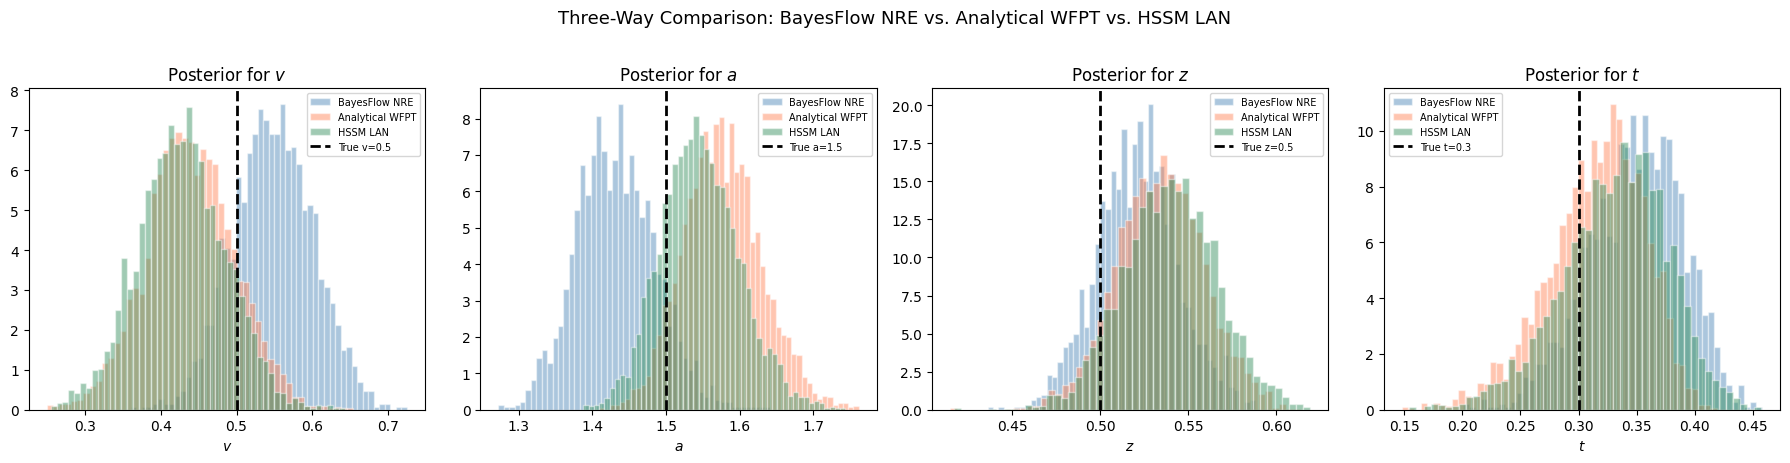

In [21]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))

for i, (name, true_val) in enumerate([
    ("v", v_true), ("a", a_true), ("z", z_true), ("t", t_true)
]):
    ax = axes[i]

    # BayesFlow ratio estimator posterior
    bf_samples = trace.posterior[name].values.flatten()
    ax.hist(bf_samples, bins=50, density=True, alpha=0.45,
            label="BayesFlow NRE", color="steelblue", edgecolor="white")

    # Analytical DDM posterior
    an_samples = trace_analytical.posterior[name].values.flatten()
    ax.hist(an_samples, bins=50, density=True, alpha=0.45,
            label="Analytical WFPT", color="coral", edgecolor="white")

    # LAN DDM posterior
    lan_samples = trace_lan.posterior[name].values.flatten()
    ax.hist(lan_samples, bins=50, density=True, alpha=0.45,
            label="HSSM LAN", color="seagreen", edgecolor="white")

    # True value
    ax.axvline(true_val, color="black", linestyle="--", linewidth=2,
               label=f"True {name}={true_val}")

    ax.set_xlabel(f"${name}$")
    ax.set_title(f"Posterior for ${name}$")
    ax.legend(fontsize=7)

plt.suptitle("Three-Way Comparison: BayesFlow NRE vs. Analytical WFPT vs. HSSM LAN", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
## Discussion

### Manual Bridge vs. HSSM Utilities

| Aspect | Manual (previous notebook) | HSSM Utilities (this notebook) |
|---|---|---|
| Lines of bridge code | ~150 | ~10 |
| vmap + VJP | Implemented inline | `make_jax_logp_funcs_from_callable` |
| PyTensor Ops | `LANLogpOp` + `LANLogpVJPOp` + `jax_funcify.register` | `make_jax_logp_ops` |
| `pm.Distribution` | `SimpleRV` + `RatioDistribution` factory | `make_distribution` |
| Parameter bounds | Not included | Built-in via `bounds` argument |
| NDT validation | Not included | Built-in (ensures t < rt) |
| Lapse model | Not included | Available via `lapse` argument |
| Simulator RV | `NotImplementedError` | Full ssm-simulators integration via `make_hssm_rv` |

### What HSSM adds for free

- **Bounds checking**: Parameters outside the training regime get a log-prob floor
  instead of unreliable neural network extrapolation
- **NDT validation**: A soft guard that replaces log-prob with a floor value (-66.1)
  when `rt - t <= 1e-15`. This is not a hard rejection -- the sampler naturally avoids
  physically impossible regions. Automatically skipped for models without a `"t"` parameter
- **Lapse model**: Mixture with a uniform/exponential lapse distribution for outlier trials
- **Trial-wise broadcasting**: Consistent handling of scalar vs. vector parameters
- **Prior/posterior predictive**: The `RandomVariable` from `make_hssm_rv` wires in the
  `ssm-simulators` RNG function, enabling `pm.sample_prior_predictive()` and
  `pm.sample_posterior_predictive()` -- as demonstrated in the PPC plot above

### The full HSSM pipeline

This notebook used HSSM's low-level utilities directly. In production, the
`hssm.HSSM()` class automates the entire workflow:

```python
import hssm

model = hssm.HSSM(
    data=df,
    model="ddm",
    loglik_kind="approx_differentiable",
    loglik=single_trial_fn,  # <-- your BayesFlow function here
    include=[
        {"name": "v", "prior": {"name": "TruncatedNormal", ...}, "formula": "v ~ 1 + condition"},
        ...
    ],
)
model.sample()
```

This adds Bambi's formula interface for hierarchical regression on any parameter,
automatic link functions, and convergence diagnostics -- all powered by the same
utilities demonstrated in this notebook.

### Three-Way Posterior Comparison

The comparison in Part 4 shows posteriors from three different likelihood strategies:

1. **BayesFlow NRE**: A ratio estimator trained on-the-fly from simulations. Learns
   the likelihood-to-evidence ratio directly, enabling amortised inference.
2. **Analytical WFPT**: The exact Wiener first-passage time density, computed via
   infinite-series expansion. This is the gold standard for the basic DDM.
3. **HSSM LAN**: A pre-trained Likelihood Approximation Network shipped with HSSM.
   Like the BayesFlow NRE, it is a neural network approximation, but it was trained
   offline on a large simulation budget and approximates the log-likelihood directly.

All three approaches use the same priors, data, and sampler settings. Close agreement
validates the BayesFlow ratio estimator against established baselines.
